In [13]:
import pandas as pd
df = pd.read_csv("taiwan_bankruptcy.csv")

df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [14]:
df.shape

(6819, 96)

In [15]:
df.columns

Index(['Bankrupt?', ' ROA(C) before interest and depreciation before interest',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' Operating Gross Margin', ' Realized Sales Gross Margin',
       ' Operating Profit Rate', ' Pre-tax net Interest Rate',
       ' After-tax net Interest Rate',
       ' Non-industry income and expenditure/revenue',
       ' Continuous interest rate (after tax)', ' Operating Expense Rate',
       ' Research and development expense rate', ' Cash flow rate',
       ' Interest-bearing debt interest rate', ' Tax rate (A)',
       ' Net Value Per Share (B)', ' Net Value Per Share (A)',
       ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons',
       ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)',
       ' Operating Profit Per Share (Yuan ¥)',
       ' Per Share Net profit before tax (Yuan ¥)',
       ' Realized Sales Gross Profit Growth Rate',
       ' Operating Profit

In [16]:
df['Bankrupt?'].value_counts()

Bankrupt?
0    6599
1     220
Name: count, dtype: int64

In [17]:
df.info

<bound method DataFrame.info of       Bankrupt?   ROA(C) before interest and depreciation before interest  \
0             1                                           0.370594          
1             1                                           0.464291          
2             1                                           0.426071          
3             1                                           0.399844          
4             1                                           0.465022          
...         ...                                                ...          
6814          0                                           0.493687          
6815          0                                           0.475162          
6816          0                                           0.472725          
6817          0                                           0.506264          
6818          0                                           0.493053          

       ROA(A) before interest and % after t

In [18]:
df.isnull().sum().sum()

np.int64(0)

In [19]:
df.dtypes.value_counts()

float64    93
int64       3
Name: count, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split

X = df.drop("Bankrupt?", axis=1)
y = df["Bankrupt?"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape

((5455, 95), (1364, 95))

Top correlated features with target (by |corr|):


c:\Users\ozgek\.conda\envs\tf310\lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\ozgek\.conda\envs\tf310\lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,feature,corr,abs_corr
0,Net Income to Total Assets,-0.315457,0.315457
1,ROA(A) before interest and % after tax,-0.282941,0.282941
2,ROA(B) before interest and depreciation after...,-0.273051,0.273051
3,ROA(C) before interest and depreciation befor...,-0.260807,0.260807
4,Debt ratio %,0.250161,0.250161
5,Net worth/Assets,-0.250161,0.250161
6,Persistent EPS in the Last Four Seasons,-0.219560,0.219560
7,Retained Earnings to Total Assets,-0.217779,0.217779
8,Net profit before tax/Paid-in capital,-0.207857,0.207857
9,Per Share Net profit before tax (Yuan ¥),-0.201395,0.201395


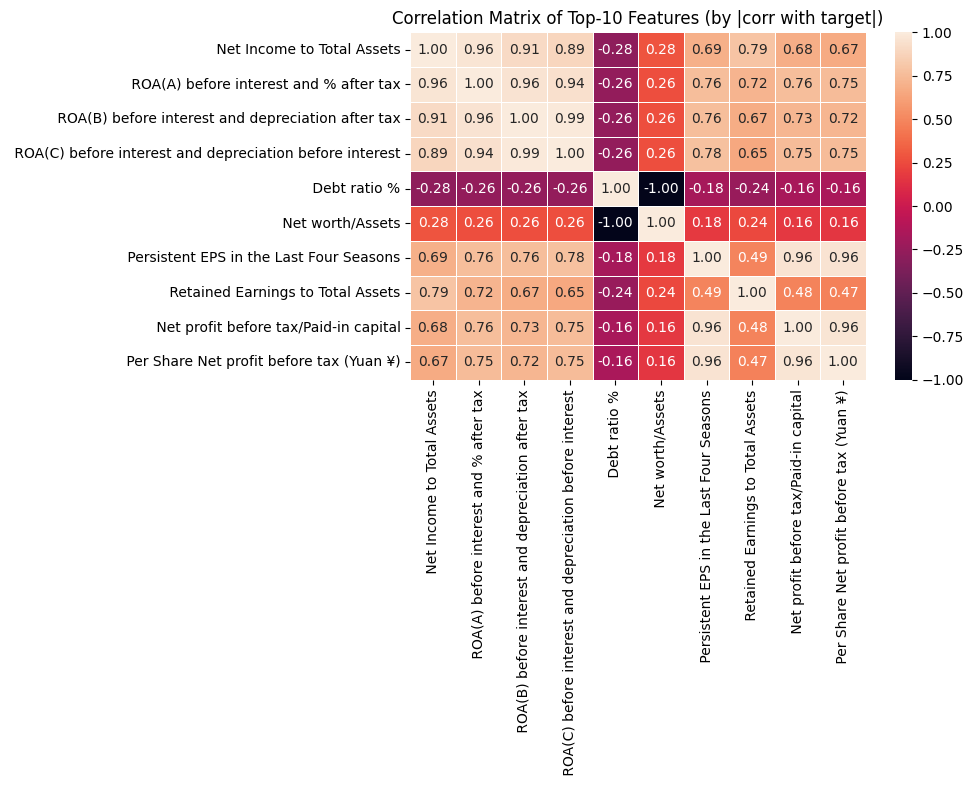

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


corr_with_target = X.apply(lambda col: col.corr(y))
corr_abs_sorted = corr_with_target.abs().sort_values(ascending=False)

top_n = 10
top_features = corr_abs_sorted.head(top_n).index.tolist()

print("Top correlated features with target (by |corr|):")
display(pd.DataFrame({
    "feature": top_features,
    "corr": corr_with_target.loc[top_features].values,
    "abs_corr": corr_abs_sorted.loc[top_features].values
}))


corr_mat = X[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, fmt=".2f", linewidths=0.5)
plt.title(f"Correlation Matrix of Top-{top_n} Features (by |corr with target|)")
plt.tight_layout()
plt.show()


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_scaled[:3]

array([[-1.76676674e-01, -1.17302631e-01, -1.35577100e-01,
        -5.42116917e-01, -5.41389269e-01,  1.47043883e-02,
         1.64140542e-02,  1.68473042e-02, -7.59091461e-03,
         1.48852606e-02,  1.48901016e+00, -7.48886613e-01,
        -6.56321000e-02, -1.51822330e-01,  5.78042787e-01,
         3.48355824e-01,  3.48178738e-01,  3.47104739e-01,
        -2.16287259e-01, -1.32579146e-01, -2.21153171e-02,
        -3.88536158e-01, -2.14232503e-01, -3.22651568e-03,
         3.20234195e-02,  9.51859644e-02,  9.42314662e-02,
         3.12532529e-01,  5.85176270e-01, -1.35407411e-02,
         8.05243258e-02,  5.24065140e-02, -1.60708700e-01,
        -3.40233370e-02, -2.04139045e-02, -2.36375116e-02,
        -1.08348338e+00,  1.08348338e+00, -1.22979617e-01,
        -3.51416790e-01, -1.64137530e-02, -3.97963041e-01,
        -2.37990590e-01, -3.68932321e-01,  1.03298479e-02,
        -4.42727167e-02, -3.92860237e-02, -6.61815413e-01,
        -4.09145548e-01, -3.00304248e-01, -1.35407412e-0

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model_log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')

model_log_reg.fit(X_train_scaled, y_train)

y_pred_log_reg = model_log_reg.predict(X_test_scaled)

print(classification_report(y_test, y_pred_log_reg))
print(confusion_matrix(y_test, y_pred_log_reg))

              precision    recall  f1-score   support

           0       0.99      0.88      0.93      1320
           1       0.19      0.82      0.30        44

    accuracy                           0.88      1364
   macro avg       0.59      0.85      0.62      1364
weighted avg       0.97      0.88      0.91      1364

[[1162  158]
 [   8   36]]


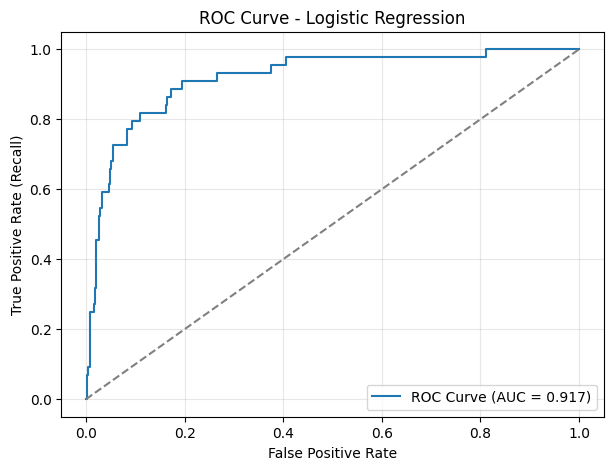

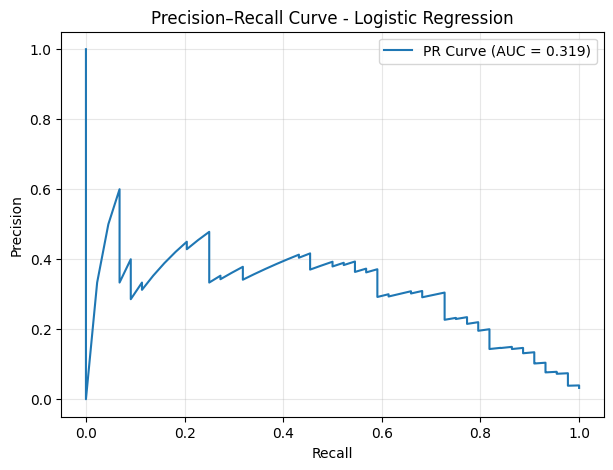

Logistic Regression ROC AUC: 0.917
Logistic Rregression PR  AUC: 0.319


In [24]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_proba_log_reg = model_log_reg.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba_log_reg)
roc_auc = roc_auc_score(y_test, y_proba_log_reg)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba_log_reg)
pr_auc = average_precision_score(y_test, y_proba_log_reg)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f"PR Curve (AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Logistic Regression ROC AUC: {roc_auc:.3f}")
print(f"Logistic Rregression PR  AUC: {pr_auc:.3f}")

In [25]:
!pip install imbalanced-learn xgboost

In [26]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: Bankrupt?
0    5279
1     176
Name: count, dtype: int64
After SMOTE: Bankrupt?
0    5279
1    5279
Name: count, dtype: int64


In [27]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(n_estimators=300, 
                          max_depth=4,
                          learning_rate=0.05,
                          subsample=0.8,
                          colsample_bytree=0.8,
                          random_state=42,
                          eval_metric="logloss"
                          )
model_xgb.fit(X_train_res, y_train_res)
y_pred_xgb = model_xgb.predict(X_test_scaled)

print("XGBoost Sonuçları")
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Sonuçları
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.42      0.64      0.51        44

    accuracy                           0.96      1364
   macro avg       0.71      0.80      0.74      1364
weighted avg       0.97      0.96      0.96      1364

[[1282   38]
 [  16   28]]


In [28]:
import numpy as np

y_proba_xgb = model_xgb.predict_proba(X_test_scaled)[:, 1]

threshold = 0.20

y_pred_xgb_thr = (y_proba_xgb >= threshold).astype(int)


print("XGBoost Sonuçları")
print(f"Threshold = {threshold}")
print(classification_report(y_test, y_pred_xgb_thr))
print(confusion_matrix(y_test, y_pred_xgb_thr))

XGBoost Sonuçları
Threshold = 0.2
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1320
           1       0.25      0.66      0.37        44

    accuracy                           0.93      1364
   macro avg       0.62      0.80      0.66      1364
weighted avg       0.96      0.93      0.94      1364

[[1235   85]
 [  15   29]]


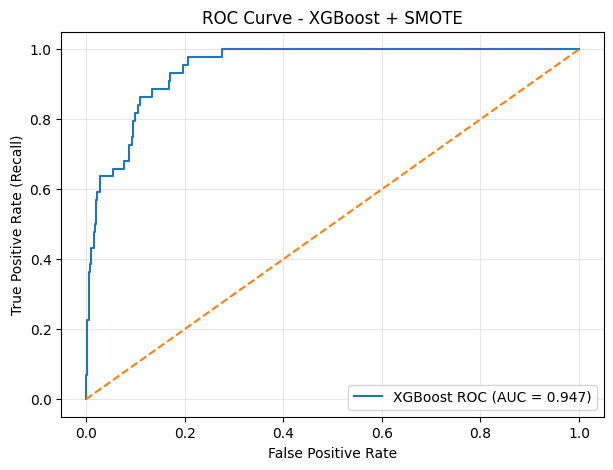

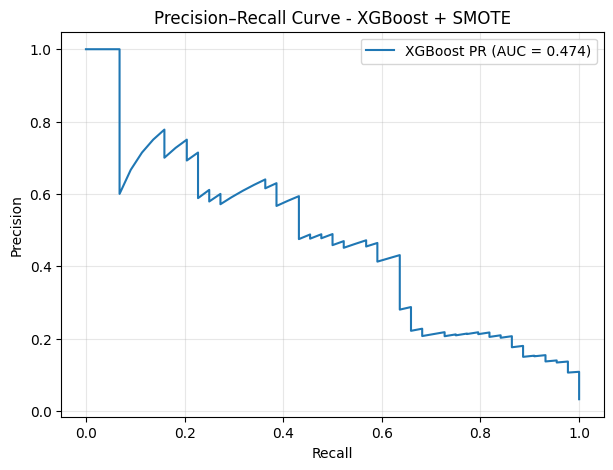

XGBoost ROC AUC: 0.947
XGBoost PR  AUC: 0.474


In [29]:
y_proba_xgb = model_xgb.predict_proba(X_test_scaled)[:, 1]

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)

plt.figure(figsize=(7,5))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost ROC (AUC = {roc_auc_xgb:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - XGBoost + SMOTE")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_proba_xgb)
pr_auc_xgb = average_precision_score(y_test, y_proba_xgb)

plt.figure(figsize=(7,5))
plt.plot(recall_xgb, precision_xgb, label=f"XGBoost PR (AUC = {pr_auc_xgb:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - XGBoost + SMOTE")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"XGBoost ROC AUC: {roc_auc_xgb:.3f}")
print(f"XGBoost PR  AUC: {pr_auc_xgb:.3f}")


In [30]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=800,
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

model_rf.fit(X_train_res, y_train_res)

y_pred_rf = model_rf.predict(X_test_scaled)

print("Random Forest Sonuçları")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Sonuçları
              precision    recall  f1-score   support

           0       0.99      0.92      0.96      1320
           1       0.25      0.75      0.37        44

    accuracy                           0.92      1364
   macro avg       0.62      0.84      0.66      1364
weighted avg       0.97      0.92      0.94      1364

[[1219  101]
 [  11   33]]


In [31]:
y_proba_rf = model_rf.predict_proba(X_test_scaled)[:, 1]

threshold = 0.35

y_pred_rf_thresh = (y_proba_rf >= threshold).astype(int)

print(f"Threshold = {threshold}")
print(classification_report(y_test, y_pred_rf_thresh))
print(confusion_matrix(y_test, y_pred_rf_thresh))

Threshold = 0.35
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      1320
           1       0.18      0.86      0.30        44

    accuracy                           0.87      1364
   macro avg       0.59      0.87      0.62      1364
weighted avg       0.97      0.87      0.91      1364

[[1151  169]
 [   6   38]]


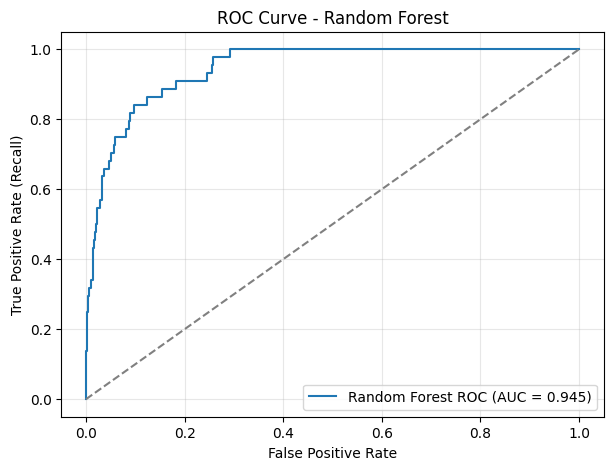

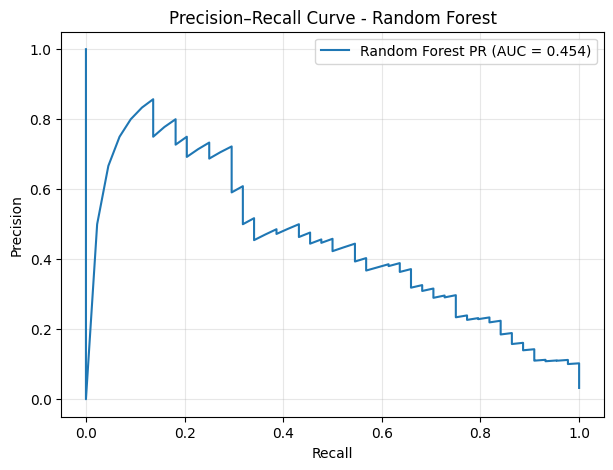

Random Forest ROC-AUC: 0.9445420110192838
Random Forest PR-AUC: 0.4539058700125409


In [32]:
y_proba_rf = model_rf.predict_proba(X_test_scaled)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(7,5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest ROC (AUC = {roc_auc_rf:.3f})")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)
pr_auc_rf = average_precision_score(y_test, y_proba_rf)

plt.figure(figsize=(7,5))
plt.plot(recall_rf, precision_rf, label=f"Random Forest PR (AUC = {pr_auc_rf:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Random Forest ROC-AUC:", roc_auc_rf)
print("Random Forest PR-AUC:", pr_auc_rf)

In [33]:
!pip install lightgbm

In [34]:
from lightgbm import LGBMClassifier

model_lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42

)

model_lgbm.fit(X_train_res, y_train_res)

y_pred_lgbm = model_lgbm.predict(X_test_scaled)

print("LGBM Sonuçları")
print(classification_report(y_test, y_pred_lgbm))
print(confusion_matrix(y_test, y_pred_lgbm))

y_proba_lgbm = model_lgbm.predict_proba(X_test_scaled)[:, 1]
roc_auc_lgbm = roc_auc_score(y_test, y_proba_lgbm)
pr_auc_lgbm = average_precision_score(y_test, y_proba_lgbm)


[LightGBM] [Info] Number of positive: 5279, number of negative: 5279
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011439 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23735
[LightGBM] [Info] Number of data points in the train set: 10558, number of used features: 94
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LGBM Sonuçları
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1320
           1       0.54      0.50      0.52        44

    accuracy                           0.97      1364
   macro avg       0.76      0.74      0.75      1364
weighted avg       0.97      0.97      0.97      1364

[[1301   19]
 [  22   22]]


c:\Users\ozgek\.conda\envs\tf310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ozgek\.conda\envs\tf310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [35]:
y_proba_lgbm = model_lgbm.predict_proba(X_test_scaled)[:,1]

threshold = 0.1

y_pred_lgbm_thresh = (y_proba_lgbm >= threshold).astype(int)

print(f"Threshold = {threshold}")
print(classification_report(y_test, y_pred_lgbm_thresh))
print(confusion_matrix(y_test, y_pred_lgbm_thresh))

c:\Users\ozgek\.conda\envs\tf310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Threshold = 0.1
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.46      0.64      0.53        44

    accuracy                           0.96      1364
   macro avg       0.72      0.81      0.76      1364
weighted avg       0.97      0.96      0.97      1364

[[1287   33]
 [  16   28]]


In [36]:
!pip install catboost

In [37]:
from catboost import CatBoostClassifier

model_cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=4,
    loss_function='Logloss',
    eval_metric='AUC',
    class_weights=[1, 10], 
    random_seed=42,
    verbose=False
)

model_cat.fit(X_train_scaled, y_train)

y_pred_cat = model_cat.predict(X_test_scaled)
y_proba_cat = model_cat.predict_proba(X_test_scaled)[:, 1]

print("CatBoost Sonuçları")
print(classification_report(y_test, y_pred_cat))
print(confusion_matrix(y_test, y_pred_cat))


CatBoost Sonuçları
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1320
           1       0.46      0.57      0.51        44

    accuracy                           0.96      1364
   macro avg       0.72      0.77      0.75      1364
weighted avg       0.97      0.96      0.97      1364

[[1291   29]
 [  19   25]]


In [38]:
y_proba_cat = model_cat.predict_proba(X_test_scaled)[:, 1]

for thr in [0.4, 0.3, 0.2, 0.1]:
    y_pred_cat_thr = (y_proba_cat >= thr).astype(int)
    print(f"\n=== CatBoost - Threshold = {thr} ===")
    print(classification_report(y_test, y_pred_cat_thr))
    print(confusion_matrix(y_test, y_pred_cat_thr))


=== CatBoost - Threshold = 0.4 ===
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.39      0.59      0.47        44

    accuracy                           0.96      1364
   macro avg       0.69      0.78      0.73      1364
weighted avg       0.97      0.96      0.96      1364

[[1280   40]
 [  18   26]]

=== CatBoost - Threshold = 0.3 ===
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1320
           1       0.37      0.68      0.48        44

    accuracy                           0.95      1364
   macro avg       0.68      0.82      0.73      1364
weighted avg       0.97      0.95      0.96      1364

[[1269   51]
 [  14   30]]

=== CatBoost - Threshold = 0.2 ===
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1320
           1       0.32      0.75      0.45        44

    accuracy        

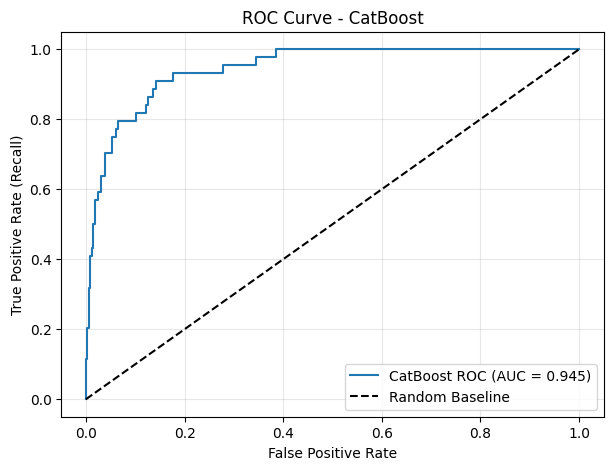

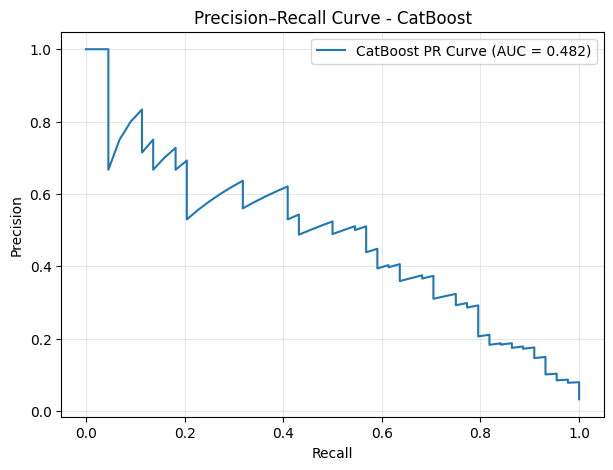

CatBoost ROC-AUC : 0.9447830578512397
CatBoost PR-AUC  : 0.48178868269204006


In [39]:
y_proba_cat = model_cat.predict_proba(X_test_scaled)[:, 1]

fpr_cat, tpr_cat, _ = roc_curve(y_test, y_proba_cat)
roc_auc_cat = roc_auc_score(y_test, y_proba_cat)

plt.figure(figsize=(7,5))
plt.plot(fpr_cat, tpr_cat, label=f"CatBoost ROC (AUC = {roc_auc_cat:.3f})")
plt.plot([0,1], [0,1], "k--", label="Random Baseline")
plt.title("ROC Curve - CatBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

precision_cat, recall_cat, _ = precision_recall_curve(y_test, y_proba_cat)
pr_auc_cat = average_precision_score(y_test, y_proba_cat)

plt.figure(figsize=(7,5))
plt.plot(recall_cat, precision_cat, label=f"CatBoost PR Curve (AUC = {pr_auc_cat:.3f})")
plt.title("Precision–Recall Curve - CatBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("CatBoost ROC-AUC :", roc_auc_cat)
print("CatBoost PR-AUC  :", pr_auc_cat)


In [40]:
from sklearn.metrics import classification_report, confusion_matrix

for thr in [0.4, 0.3, 0.2, 0.1]:
    y_pred_thr = (y_proba_cat >= thr).astype(int)
    print(f"\nThreshold = {thr}")
    print(classification_report(y_test, y_pred_thr))
    print(confusion_matrix(y_test, y_pred_thr))


Threshold = 0.4
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.39      0.59      0.47        44

    accuracy                           0.96      1364
   macro avg       0.69      0.78      0.73      1364
weighted avg       0.97      0.96      0.96      1364

[[1280   40]
 [  18   26]]

Threshold = 0.3
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1320
           1       0.37      0.68      0.48        44

    accuracy                           0.95      1364
   macro avg       0.68      0.82      0.73      1364
weighted avg       0.97      0.95      0.96      1364

[[1269   51]
 [  14   30]]

Threshold = 0.2
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1320
           1       0.32      0.75      0.45        44

    accuracy                           0.94      1364
   macro avg       0.65

In [41]:
from sklearn.svm import SVC

model_svm = SVC(
    kernel = "rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)

model_svm.fit(X_train_scaled, y_train)

y_pred_svm = model_svm.predict(X_test_scaled)

print("SVM Sonuçları (default threshold = 0.50)")
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

y_proba_svm = model_svm.predict_proba(X_test_scaled)[:, 1]

roc_auc_svm = roc_auc_score(y_test, y_proba_svm)
pr_auc_svm = average_precision_score(y_test, y_proba_svm)

SVM Sonuçları (default threshold = 0.50)
              precision    recall  f1-score   support

           0       0.99      0.91      0.95      1320
           1       0.19      0.64      0.29        44

    accuracy                           0.90      1364
   macro avg       0.59      0.77      0.62      1364
weighted avg       0.96      0.90      0.92      1364

[[1199  121]
 [  16   28]]


In [42]:
threshold = 0.05

y_pred_svm_thresh = (y_proba_svm >= threshold).astype(int)

print(f"Threshold = {threshold}")
print(classification_report(y_test, y_pred_svm_thresh))
print(confusion_matrix(y_test, y_pred_svm_thresh))

Threshold = 0.05
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      1320
           1       0.16      0.70      0.26        44

    accuracy                           0.87      1364
   macro avg       0.57      0.79      0.59      1364
weighted avg       0.96      0.87      0.91      1364

[[1156  164]
 [  13   31]]


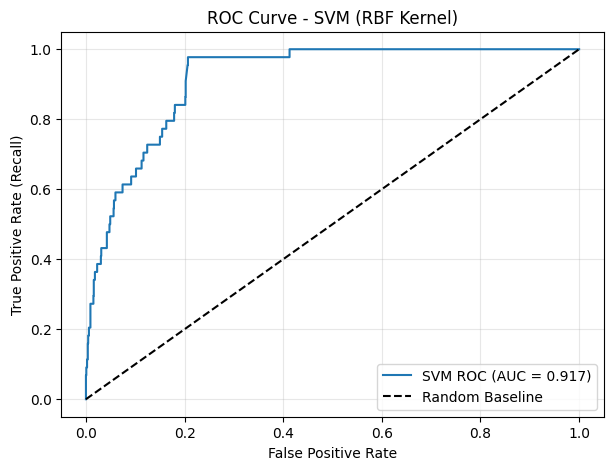

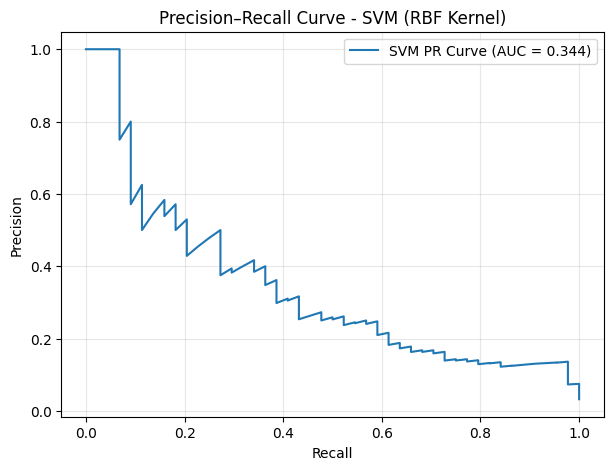

SVM ROC-AUC : 0.9174070247933885
SVM PR-AUC  : 0.34361953079052104


In [43]:
y_proba_svm = model_svm.predict_proba(X_test_scaled)[:, 1]

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
roc_auc_svm = roc_auc_score(y_test, y_proba_svm)

plt.figure(figsize=(7,5))
plt.plot(fpr_svm, tpr_svm, label=f"SVM ROC (AUC = {roc_auc_svm:.3f})")
plt.plot([0,1], [0,1], "k--", label="Random Baseline")
plt.title("ROC Curve - SVM (RBF Kernel)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_proba_svm)
pr_auc_svm = average_precision_score(y_test, y_proba_svm)

plt.figure(figsize=(7,5))
plt.plot(recall_svm, precision_svm, label=f"SVM PR Curve (AUC = {pr_auc_svm:.3f})")
plt.title("Precision–Recall Curve - SVM (RBF Kernel)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("SVM ROC-AUC :", roc_auc_svm)
print("SVM PR-AUC  :", pr_auc_svm)

In [44]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [45]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model_nn1 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(1, activation='sigmoid') 
])

model_nn1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_nn1.summary()

c:\Users\ozgek\.conda\envs\tf310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,105 (12.13 KB)

 Trainable params: 3,105 (12.13 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
history_nn1 = model_nn1.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight={0:1, 1:10},
    verbose=1
)

Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8119 - loss: 0.7127 - val_accuracy: 0.8698 - val_loss: 0.3696
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8951 - loss: 0.4840 - val_accuracy: 0.9093 - val_loss: 0.2988
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9159 - loss: 0.4000 - val_accuracy: 0.9294 - val_loss: 0.2465
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9244 - loss: 0.3600 - val_accuracy: 0.9358 - val_loss: 0.2231
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9308 - loss: 0.3373 - val_accuracy: 0.9303 - val_loss: 0.2239
Epoch 6/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9340 - loss: 0.3195 - val_accuracy: 0.9368 - val_loss: 0.2171
Epoch 7/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9374 - loss: 0.3087 - val_accuracy: 0.9303 - val_loss: 0.2174
Epoch 8/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9377 - loss: 0.3000 - val_accuracy: 0.

In [48]:
y_proba_nn1 = model_nn1.predict(X_test_scaled).ravel()
y_pred_nn1 = (y_proba_nn1 >= 0.5).astype(int)

print("Neural Network Sonuçları")
print(classification_report(y_test, y_pred_nn1))
print(confusion_matrix(y_test, y_pred_nn1))

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Neural Network Sonuçları
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1320
           1       0.32      0.43      0.37        44

    accuracy                           0.95      1364
   macro avg       0.65      0.70      0.67      1364
weighted avg       0.96      0.95      0.96      1364

[[1280   40]
 [  25   19]]


In [49]:
y_proba_nn = model_nn1.predict(X_test_scaled).ravel()

for threshold in [0.4, 0.3, 0.2]:
    y_pred_thr = (y_proba_nn >= threshold).astype(int)
    print(f"\nThreshold = {threshold}")
    print(classification_report(y_test, y_pred_thr))
    print(confusion_matrix(y_test, y_pred_thr))

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Threshold = 0.4
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1320
           1       0.28      0.50      0.36        44

    accuracy                           0.94      1364
   macro avg       0.63      0.73      0.66      1364
weighted avg       0.96      0.94      0.95      1364

[[1263   57]
 [  22   22]]

Threshold = 0.3
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      1320
           1       0.22      0.52      0.31        44

    accuracy                           0.93      1364
   macro avg       0.60      0.73      0.64      1364
weighted avg       0.96      0.93      0.94      1364

[[1240   80]
 [  21   23]]

Threshold = 0.2
              precision    recall  f1-score   support

           0       0.99      0.92      0.95      1320
           1       0.22      0.64      0.33        44

    accuracy                          

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


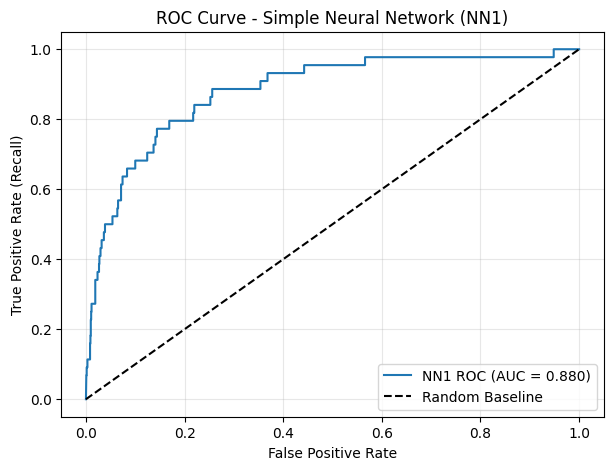

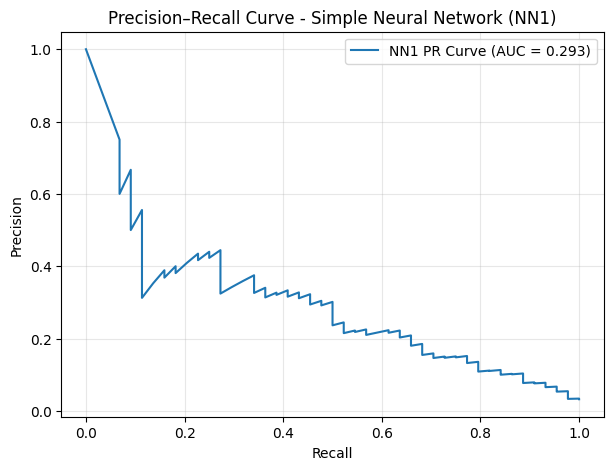

NN1 ROC-AUC : 0.8803288567493113
NN1 PR-AUC  : 0.2934767740826906


In [50]:
y_proba_nn1 = model_nn1.predict(X_test_scaled).ravel()

fpr_nn1, tpr_nn1, _ = roc_curve(y_test, y_proba_nn1)
roc_auc_nn1 = roc_auc_score(y_test, y_proba_nn1)

plt.figure(figsize=(7,5))
plt.plot(fpr_nn1, tpr_nn1, label=f"NN1 ROC (AUC = {roc_auc_nn1:.3f})")
plt.plot([0,1], [0,1], "k--", label="Random Baseline")
plt.title("ROC Curve - Simple Neural Network (NN1)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

precision_nn1, recall_nn1, _ = precision_recall_curve(y_test, y_proba_nn1)
pr_auc_nn1 = average_precision_score(y_test, y_proba_nn1)

plt.figure(figsize=(7,5))
plt.plot(recall_nn1, precision_nn1, label=f"NN1 PR Curve (AUC = {pr_auc_nn1:.3f})")
plt.title("Precision–Recall Curve - Simple Neural Network (NN1)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("NN1 ROC-AUC :", roc_auc_nn1)
print("NN1 PR-AUC  :", pr_auc_nn1)


In [51]:
model_complex = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')  
])

model_complex.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_complex.summary()

c:\Users\ozgek\.conda\envs\tf310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │        12,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,065 (94.00 KB)

 Trainable params: 23,617 (92.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [52]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history_complex = model_complex.fit(
    X_train_scaled, y_train,
    epochs=80,
    batch_size=64,
    validation_split=0.2,
    class_weight={0: 1., 1: 25.},   # pozitif sınıfa ekstra ağırlık
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/80
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6753 - loss: 1.5192 - val_accuracy: 0.6169 - val_loss: 0.6746
Epoch 2/80
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6829 - loss: 1.3757 - val_accuracy: 0.6902 - val_loss: 0.6474
Epoch 3/80
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6739 - loss: 1.1749 - val_accuracy: 0.7406 - val_loss: 0.6175
Epoch 4/80
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6895 - loss: 1.1500 - val_accuracy: 0.7461 - val_loss: 0.5938
Epoch 5/80
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6794 - loss: 1.0708 - val_accuracy: 0.7406 - val_loss: 0.5957
Epoch 6/80
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6794 - loss: 1.0266 - val_accuracy: 0.7443 - val_loss: 0.5910
Epoch 7/80
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6964 - loss: 0.9994 - val_accuracy: 0.7525 - val_loss: 0.5853
Epoch 8/80
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6923 - loss: 0.9767 - val_accuracy: 0.7525 - val_loss

In [53]:
y_proba_complex = model_complex.predict(X_test_scaled).ravel()

for thr in [0.4, 0.3, 0.2]:
    y_pred_complex = (y_proba_complex >= thr).astype(int)
    print(f"\n=== Complex NN - Threshold = {thr} ===")
    print(classification_report(y_test, y_pred_complex))
    print(confusion_matrix(y_test, y_pred_complex))

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

=== Complex NN - Threshold = 0.4 ===
              precision    recall  f1-score   support

           0       0.99      0.85      0.92      1320
           1       0.16      0.86      0.27        44

    accuracy                           0.85      1364
   macro avg       0.58      0.86      0.60      1364
weighted avg       0.97      0.85      0.90      1364

[[1125  195]
 [   6   38]]

=== Complex NN - Threshold = 0.3 ===
              precision    recall  f1-score   support

           0       0.99      0.81      0.90      1320
           1       0.13      0.86      0.23        44

    accuracy                           0.82      1364
   macro avg       0.56      0.84      0.56      1364
weighted avg       0.97      0.82      0.87      1364

[[1075  245]
 [   6   38]]

=== Complex NN - Threshold = 0.2 ===
              precision    recall  f1-score   support

           0       1.00      0.78      0.87      1320
           1       0.12      0

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


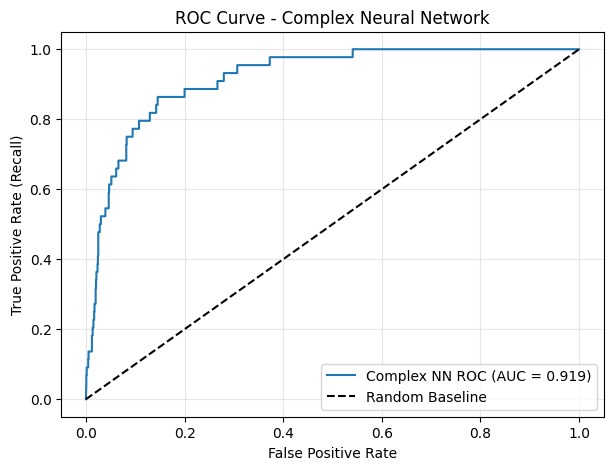

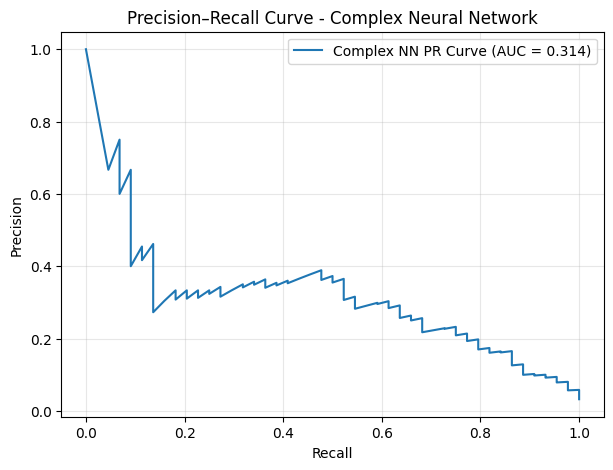

Complex NN ROC-AUC : 0.9192665289256199
Complex NN PR-AUC  : 0.3140270350701183


In [54]:
y_proba_cnn = model_complex.predict(X_test_scaled).ravel()

fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_proba_cnn)
roc_auc_cnn = roc_auc_score(y_test, y_proba_cnn)

plt.figure(figsize=(7,5))
plt.plot(fpr_cnn, tpr_cnn, label=f"Complex NN ROC (AUC = {roc_auc_cnn:.3f})")
plt.plot([0,1], [0,1], "k--", label="Random Baseline")
plt.title("ROC Curve - Complex Neural Network")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

precision_cnn, recall_cnn, _ = precision_recall_curve(y_test, y_proba_cnn)
pr_auc_cnn = average_precision_score(y_test, y_proba_cnn)

plt.figure(figsize=(7,5))
plt.plot(recall_cnn, precision_cnn, label=f"Complex NN PR Curve (AUC = {pr_auc_cnn:.3f})")
plt.title("Precision–Recall Curve - Complex Neural Network")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Complex NN ROC-AUC :", roc_auc_cnn)
print("Complex NN PR-AUC  :", pr_auc_cnn)


In [55]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, average_precision_score

results = []

def add_model_result(name, y_test, y_pred, y_proba):
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=[1], average=None
    )
    results.append({
        "Model": name,
        "Precision_1": float(prec[0]),
        "Recall_1": float(rec[0]),
        "F1_1": float(f1[0]),
        "ROC_AUC": float(roc_auc_score(y_test, y_proba)),
        "PR_AUC": float(average_precision_score(y_test, y_proba))
    })

def pred_from_threshold(y_proba, thr):
    return (y_proba >= thr).astype(int)

THR = 0.4

# Logistic Regression
add_model_result("Logistic Regression", y_test, y_pred_log_reg, y_proba_log_reg)
add_model_result(f"Logistic Regression (thr={THR})", y_test,
                 pred_from_threshold(y_proba_log_reg, THR), y_proba_log_reg)

# Random Forest
add_model_result("Random Forest", y_test, y_pred_rf, y_proba_rf)
add_model_result(f"Random Forest (thr={THR})", y_test,
                 pred_from_threshold(y_proba_rf, THR), y_proba_rf)

# XGBoost
add_model_result("XGBoost", y_test, y_pred_xgb, y_proba_xgb)
add_model_result(f"XGBoost (thr={THR})", y_test,
                 pred_from_threshold(y_proba_xgb, THR), y_proba_xgb)

# LightGBM
add_model_result("LightGBM", y_test, y_pred_lgbm, y_proba_lgbm)
add_model_result(f"LightGBM (thr={THR})", y_test,
                 pred_from_threshold(y_proba_lgbm, THR), y_proba_lgbm)

# SVM
add_model_result("SVM (thr=0.5)", y_test, (y_proba_svm >= 0.5).astype(int), y_proba_svm)
add_model_result(f"SVM (thr={THR})", y_test,
                 pred_from_threshold(y_proba_svm, THR), y_proba_svm)

# CatBoost
add_model_result("CatBoost", y_test, y_pred_cat, y_proba_cat)
add_model_result(f"CatBoost (thr={THR})", y_test,
                 pred_from_threshold(y_proba_cat, THR), y_proba_cat)

# Neural Networks
add_model_result("Basic NN", y_test, y_pred_nn1, y_proba_nn1)
add_model_result("Complex NN", y_test, y_pred_complex, y_proba_cnn)

df_results = pd.DataFrame(results)
df_results = df_results.sort_values("F1_1", ascending=False).reset_index(drop=True)

In [56]:
pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [57]:
print(df_results.to_markdown())

|    | Model                         |   Precision_1 |   Recall_1 |     F1_1 |   ROC_AUC |   PR_AUC |
|---:|:------------------------------|--------------:|-----------:|---------:|----------:|---------:|
|  0 | LightGBM                      |      0.536585 |   0.5      | 0.517647 |  0.950448 | 0.55505  |
|  1 | CatBoost                      |      0.462963 |   0.568182 | 0.510204 |  0.944783 | 0.481789 |
|  2 | XGBoost                       |      0.424242 |   0.636364 | 0.509091 |  0.947142 | 0.473976 |
|  3 | LightGBM (thr=0.4)            |      0.511628 |   0.5      | 0.505747 |  0.950448 | 0.55505  |
|  4 | CatBoost (thr=0.4)            |      0.393939 |   0.590909 | 0.472727 |  0.944783 | 0.481789 |
|  5 | XGBoost (thr=0.4)             |      0.363636 |   0.636364 | 0.46281  |  0.947142 | 0.473976 |
|  6 | Random Forest                 |      0.246269 |   0.75     | 0.370787 |  0.944542 | 0.453906 |
|  7 | Basic NN                      |      0.322034 |   0.431818 | 0.368932 |  0.

In [58]:
idx_rec = df_results["Recall_1"].idxmax()
print("\nEn yüksek Recall_1:")
print(df_results.loc[idx_rec, ["Model", "Recall_1"]])

idx_pr = df_results["PR_AUC"].idxmax()
print("\nEn yüksek PR-AUC:")
print(df_results.loc[idx_pr, ["Model", "PR_AUC"]])

idx_f1 = df_results["F1_1"].idxmax()
print("\nEn yüksek F1_1:")
print(df_results.loc[idx_f1, ["Model", "F1_1", "Recall_1", "Precision_1", "PR_AUC", "ROC_AUC"]])



En yüksek Recall_1:
Model       Complex NN
Recall_1      0.886364
Name: 12, dtype: object

En yüksek PR-AUC:
Model     LightGBM
PR_AUC     0.55505
Name: 0, dtype: object

En yüksek F1_1:
Model          LightGBM
F1_1           0.517647
Recall_1            0.5
Precision_1    0.536585
PR_AUC          0.55505
ROC_AUC        0.950448
Name: 0, dtype: object


In [59]:
THR = 0.4
best_model_name = df_results.loc[idx_f1, "Model"]
print("Best model:", best_model_name)

# -------------------------
# LightGBM
# -------------------------
if "LightGBM" in best_model_name:
    best_y_proba = y_proba_lgbm
    if "(thr=" in best_model_name:
        best_y_pred = (best_y_proba >= THR).astype(int)
    else:
        best_y_pred = y_pred_lgbm

# -------------------------
# XGBoost
# -------------------------
elif "XGBoost" in best_model_name:
    best_y_proba = y_proba_xgb
    if "(thr=" in best_model_name:
        best_y_pred = (best_y_proba >= THR).astype(int)
    else:
        best_y_pred = y_pred_xgb

# -------------------------
# Random Forest
# -------------------------
elif "Random Forest" in best_model_name:
    best_y_proba = y_proba_rf
    if "(thr=" in best_model_name:
        best_y_pred = (best_y_proba >= THR).astype(int)
    else:
        best_y_pred = y_pred_rf

# -------------------------
# CatBoost
# -------------------------
elif "CatBoost" in best_model_name:
    best_y_proba = y_proba_cb
    if "(thr=" in best_model_name:
        best_y_pred = (best_y_proba >= THR).astype(int)
    else:
        best_y_pred = y_pred_cb

# -------------------------
# Logistic Regression
# -------------------------
elif "Logistic Regression" in best_model_name:
    best_y_proba = y_proba_log
    if "(thr=" in best_model_name:
        best_y_pred = (best_y_proba >= THR).astype(int)
    else:
        best_y_pred = y_pred_log

# -------------------------
# SVM
# -------------------------
elif "SVM" in best_model_name:
    best_y_proba = y_score_svm
    if "(thr=" in best_model_name:
        best_y_pred = (best_y_proba >= THR).astype(int)
    else:
        best_y_pred = (best_y_proba >= 0.5).astype(int)

# -------------------------
# Neural Networks
# -------------------------
elif "Simple NN" in best_model_name:
    best_y_proba = y_proba_nn
    best_y_pred  = y_pred_nn

elif "Complex NN" in best_model_name:
    best_y_proba = y_proba_cnn
    best_y_pred  = y_pred_cnn

else:
    raise ValueError("Best model eşleştirilemedi")


Best model: LightGBM


In [60]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, best_y_pred))

print("\nClassification Report:")
print(classification_report(y_test, best_y_pred, digits=3))

Confusion Matrix:
[[1301   19]
 [  22   22]]

Classification Report:
              precision    recall  f1-score   support

           0      0.983     0.986     0.984      1320
           1      0.537     0.500     0.518        44

    accuracy                          0.970      1364
   macro avg      0.760     0.743     0.751      1364
weighted avg      0.969     0.970     0.969      1364



In [61]:
from sklearn.metrics import f1_score

ths = np.linspace(0, 1, 501)
f1s = [f1_score(y_test, (best_y_proba >= t).astype(int)) for t in ths]

best_thr = ths[int(np.argmax(f1s))]
print("Best threshold (Simple dataset):", best_thr)
print("Best F1:", max(f1s))

Best threshold (Simple dataset): 0.324
Best F1: 0.5434782608695652


In [62]:
best_y_pred_opt = (best_y_proba >= best_thr).astype(int)

print("Confusion Matrix (opt thr):")
print(confusion_matrix(y_test, best_y_pred_opt))

print("\nClassification Report (opt thr):")
print(classification_report(y_test, best_y_pred_opt, digits=3))

Confusion Matrix (opt thr):
[[1297   23]
 [  19   25]]

Classification Report (opt thr):
              precision    recall  f1-score   support

           0      0.986     0.983     0.984      1320
           1      0.521     0.568     0.543        44

    accuracy                          0.969      1364
   macro avg      0.753     0.775     0.764      1364
weighted avg      0.971     0.969     0.970      1364



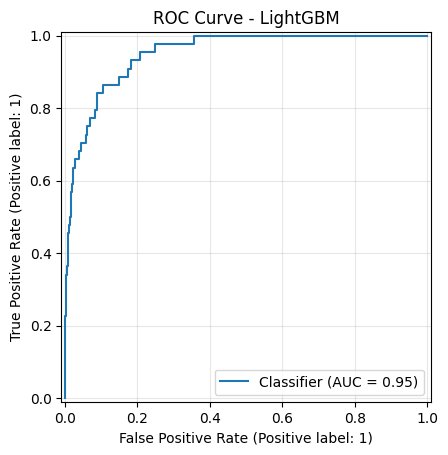

In [63]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, best_y_proba)
plt.title(f"ROC Curve - {best_model_name}")
plt.grid(alpha=0.3)
plt.show()

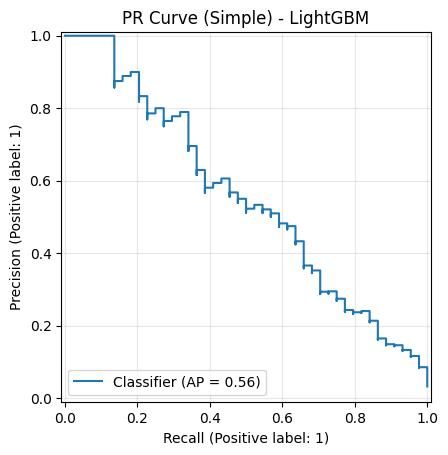

In [64]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, best_y_proba)
plt.title(f"PR Curve (Simple) - {best_model_name}")
plt.grid(alpha=0.3)
plt.show()


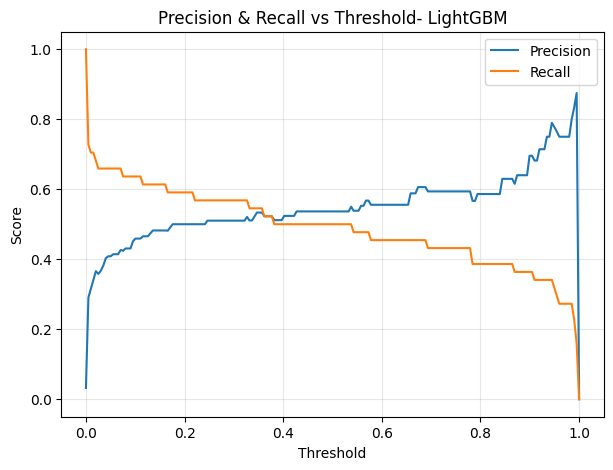

In [65]:
from sklearn.metrics import precision_score, recall_score

ths = np.linspace(0, 1, 200)
precisions, recalls = [], []

for t in ths:
    y_pred_t = (best_y_proba >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t))

plt.figure(figsize=(7,5))
plt.plot(ths, precisions, label="Precision")
plt.plot(ths, recalls, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title(f"Precision & Recall vs Threshold- {best_model_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [66]:
model_map = {
    "LightGBM": model_lgbm,
    "XGBoost": model_xgb,
    "Random Forest": model_rf,
    "CatBoost": model_cat,
    "Logistic Regression": model_log_reg,
    "SVM": model_svm,
    "Simple NN": model_nn1,
    "Complex NN": model_complex,
}

best_model = model_map[best_model_name]

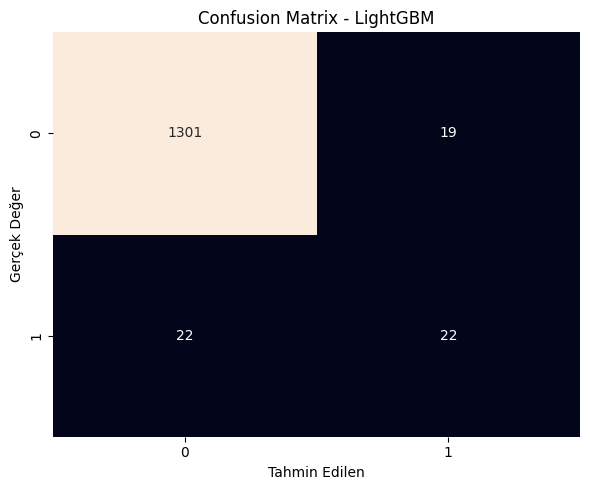

In [68]:
cm = confusion_matrix(y_test, best_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cbar=False)
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek Değer")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()


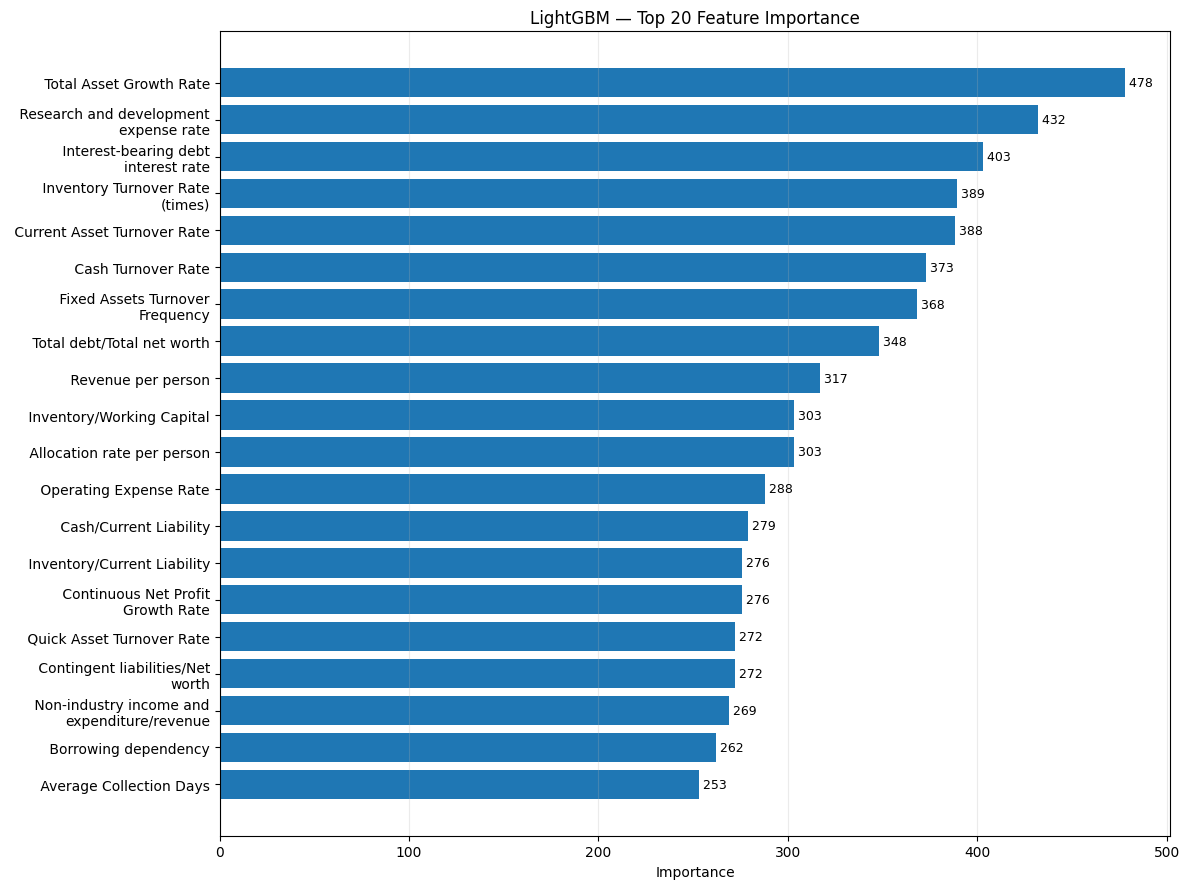

In [70]:
feature_names = X_train.columns

import textwrap

def plot_top_feature_importance_pretty(best_model, feature_names, top_n=20, title=None, wrap_width=28):
    # importance'ı al
    if hasattr(best_model, "feature_importances_"):
        importances = np.array(best_model.feature_importances_, dtype=float)
    elif hasattr(best_model, "coef_"):
        importances = np.abs(np.array(best_model.coef_)).ravel()
    else:
        raise ValueError("Bu model için feature importance yok (feature_importances_ / coef_ bulunamadı).")

    fi = pd.DataFrame({"feature": feature_names, "importance": importances})
    fi = fi.sort_values("importance", ascending=False).head(top_n)

    # uzun isimleri satıra böl (wrap)
    fi["feature_wrapped"] = fi["feature"].apply(lambda s: "\n".join(textwrap.wrap(str(s), width=wrap_width)))

    # dinamik boyut: feature sayısına göre yükseklik ayarla
    height = max(6, 0.45 * len(fi))
    plt.figure(figsize=(12, height))

    # yatay bar (en büyük üstte)
    plt.barh(fi["feature_wrapped"][::-1], fi["importance"][::-1])
    plt.xlabel("Importance")
    plt.title(title or f"{getattr(best_model, '__class__', type(best_model)).__name__} — Top {top_n} Feature Importance")

    # grid
    plt.grid(axis="x", alpha=0.25)

    # bar sonuna değer yaz
    vals = fi["importance"].to_numpy()[::-1]
    for i, v in enumerate(vals):
        plt.text(v, i, f" {v:.0f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

# kullanım
plot_top_feature_importance_pretty(
    best_model,
    feature_names=feature_names,
    top_n=20,
    title=f"{best_model_name} — Top 20 Feature Importance",
    wrap_width=28
)
